# Cross-checking `gw_response` against `lisagwresponse`

This notebook validates `gw_response`'s LISA single-link response against the
independently-developed [`lisagwresponse`](https://gitlab.in2p3.fr/lisa-simulation/gw-response)
package (J.-B. Bayle et al.), on two axes:

1. **Output**: do the two codes agree on the actual physics?
2. **Performance**: how does `gw_response`'s JAX/JIT-compiled approach
   compare to `lisagwresponse`'s time-domain, spline-interpolation approach?

**Requirement**: `lisagwresponse` is *not* a dependency of `gw_response` (not
even an optional one) — it's only needed to run this comparison notebook.
Install it yourself first:

```
pip install lisagwresponse
```


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.interpolate import make_interp_spline

import gw_response as gwr

try:
    from lisagwresponse import GalacticBinary
    from lisaconstants.indexing import LINKS
except ImportError as exc:
    raise ImportError(
        "This notebook needs the independent 'lisagwresponse' package, which "
        "is not a gw_response dependency. Install it with `pip install "
        "lisagwresponse` and re-run this notebook."
    ) from exc


/home/pieroni/.pyenv/versions/3.13.5/envs/ligo_sgwb/lib/python3.13/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


## 1. Setup: matching `lisagwresponse`'s conventions

`Response.get_single_link_response_delay_td` computes the raw per-link (not
TDI-combined) Doppler response by evaluating the waveform directly at each
link's emission/reception times and differencing. Evaluating at the
antipodal sky position `(theta_anti, phi_anti) = (pi - theta0, phi0 + pi)`
(below) instead of `(theta0, phi0)`, and multiplying the returned array by
`-1`, gives the same physics in the convention that matches
`lisagwresponse` directly.

### Convention differences

Two independently-developed codes for the same physics rarely share
*identical* normalization conventions. Comparing against `lisagwresponse`
surfaced three, all well-understood -- **not fixed silently**, since they
reflect genuine convention choices, not bugs:

1. **Wavevector sign.** `gw_response`'s `unit_vec(theta, phi)` points from
   the detector *towards* the sky position. `lisagwresponse`'s wave
   propagation vector `k` points from the sky position *towards* the
   detector (the standard "incoming wave" convention) — i.e. the two are
   antiparallel. Evaluating at the antipodal sky position `(pi - theta,
   phi + pi)` flips `unit_vec` and undoes this.
2. **Polarization tensor normalization**: fixed at the source --
   `polarization_tensors_PC` now matches Hartwig, Lilley, Muratore &
   Pieroni (arXiv:2303.15929) eq. 2.10 exactly, which already matches
   `lisagwresponse`'s (unnormalized) antenna pattern
   (`dot(n,u)**2 - dot(n,v)**2`) convention. Nothing left to correct here.
3. **Cross-polarization sign.** `gw_response`'s `(u, v)` basis is fixed so
   `(u, v, unit_vec)` is right-handed, leaving `e_cross` (unlike `e_plus`,
   which only depends on `u`/`v` through the sign-insensitive
   `u⊗u - v⊗v`) with the opposite sign from `lisagwresponse`'s antenna
   pattern. The same antipodal substitution as (1) flips `e_cross`'s sign
   too (it flips `dk_dphi`, which `e_cross` is linear in, but not
   `dk_dtheta`), undoing this for free.

Evaluating at `(theta_anti, phi_anti)` instead of `(theta0, phi0)` undoes
(1) and (3) together; (2) needs no correction anymore. What remains after
both is a single, plain `-1` on the returned array -- a residual overall
sign convention that neither the antipodal substitution nor the
polarization-tensor renormalization touches.


In [2]:
lisa = gwr.LISA()
ps = gwr.PhysicalConstants()
arm_labels = [12, 23, 31, 21, 32, 13]  # gw_response's arm ordering convention
ref_links = list(LINKS)  # lisagwresponse's own arm ordering convention
c = float(ps.light_speed)

# Sky position, in gw_response's (theta, phi) convention (colatitude, longitude).
theta0, phi0 = jnp.asarray(1.1), jnp.asarray(0.7)

# Antipodal sky position: undoes conventions (1) and (3) from section 1 above, by
# flipping unit_vec (via dk_dphi) and, with it, e_cross's sign.
theta_anti, phi_anti = jnp.pi - theta0, phi0 + jnp.pi

# lisagwresponse expects (right-ascension, declination) in the same Cartesian frame
# as gw_response's orbits. This requires converting from gw_response's (theta, phi)
# to (ra, dec) using:
ra, dec = phi0, np.pi / 2 - theta0

# A generic monochromatic source: nonzero iota so both polarizations contribute (not
# just an isolated plus- or cross-only special case). psi here is kept at 0
A = 1e-21
iota, psi = 0.7, 0.0
dt = 1.0
n = 8192
df = 1.0 / (n * dt)
f0 = 41 * df  # a representative frequency for the shared waveform definitions below


def amplitude_plus_fn(tau, waveform_params):
    return A * (1 + jnp.cos(iota) ** 2)


def amplitude_cross_fn(tau, waveform_params):
    return 2 * A * jnp.cos(iota)


def phase_fn(tau, waveform_params):
    return 2 * jnp.pi * f0 * tau + jnp.pi  # +pi to match hplus_source = -A(..)*cos(phase)


## 2. Moving spacecraft: matching `lisagwresponse`'s time-domain response

Both codes see the constellation's **real, time-evolving** orbital motion
here. Two `gw_response` methods can compute a single-link response for a
genuinely moving detector:

1. **Delay-based, exact** (`get_single_link_response_delay_td`,
   `freeze_geometry=False`): no discretization of the geometry's
   time-dependence at all -- every sample's emitter position is
   individually backdated by its own light-travel time.
2. **Segment-stacking** (`get_single_link_response_segmented_td`): chunk
   the duration into short windows, and within each one, expand the exact
   delay formula to first order (in time) around the window's own
   midpoint -- one automatic-differentiation call per window rather than
   one geometry lookup per sample. Converges to the exact answer
   *quadratically* as the chunks shrink -- see section 2b below.

We expect floating-point agreement from method 1, and a small, well-behaved
residual from segment-stacking's own approximation, on top of the same sign
convention from section 1.

To keep both codes looking at *exactly* the same orbital trajectory (rather
than also comparing two different orbit models), we sample `gw_response`'s
own analytical LISA orbits finely and feed `lisagwresponse` spline
interpolants built from those samples -- so the only difference under test
is the response *algorithm*, not the orbit.


In [3]:
duration_days = 30
dt_moving = 300.0
n_moving = int(duration_days * 86400 / dt_moving)
t_moving = np.arange(n_moving) * dt_moving  # NumPy: fed to lisagwresponse below
margin = 2000.0  # seconds of extra orbit-sample margin for light-travel-time reach-back

# Sample gw_response's own analytical orbits finely (hourly), then build
# spline interpolants lisagwresponse can query at arbitrary times -- SciPy
# splines need NumPy, so this is where the JAX/NumPy boundary sits.
sample_dt = 3600.0
t_orbit = np.arange(-margin, n_moving * dt_moving + margin, sample_dt)
years_orbit = jnp.asarray(t_orbit) / ps.yr
pos_t = np.asarray(lisa.vertex_positions(years_orbit))  # (len(t_orbit), 3, 3) xyz,sat
arms_t = np.asarray(lisa.detector_arms(years_orbit))  # (len(t_orbit), 3, 6) xyz,arm
arm_len_t = np.linalg.norm(arms_t, axis=1)  # (len(t_orbit), 6)

x_interp = {sc: make_interp_spline(t_orbit, pos_t[:, 0, sc - 1], k=3) for sc in (1, 2, 3)}
y_interp = {sc: make_interp_spline(t_orbit, pos_t[:, 1, sc - 1], k=3) for sc in (1, 2, 3)}
z_interp = {sc: make_interp_spline(t_orbit, pos_t[:, 2, sc - 1], k=3) for sc in (1, 2, 3)}
ltt_interp = {
    label: make_interp_spline(t_orbit, arm_len_t[:, i] / c, k=3)
    for i, label in enumerate(arm_labels)
}

sc1_motion = pos_t[:, 0, 0].max() - pos_t[:, 0, 0].min()
print(f"Over {duration_days} days, satellite 1's x-coordinate alone moves {sc1_motion / 1e3:,.0f} km")

df_moving = 1.0 / (n_moving * dt_moving)
f0_moving = round(0.01 / df_moving) * df_moving  # ~10 mHz, near an exact bin

ref_source_moving = GalacticBinary(
    A=A, f=f0_moving, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
    ra=ra, dec=dec, x=x_interp, y=y_interp, z=z_interp, ltt=ltt_interp,
    orbits="unused.h5", shift_sun="never",
)
ref_response_moving = ref_source_moving.compute_gw_response(t_moving, LINKS)  # true moving geometry


Over 30 days, satellite 1's x-coordinate alone moves 19,682,499 km


In [4]:
t_moving_jnp = jnp.asarray(t_moving)
times_in_years_moving = t_moving_jnp / ps.yr


def phase_fn_moving_shifted(tau, waveform_params):
    return 2 * jnp.pi * f0_moving * tau + jnp.pi  # matches -amp*cos(phase) convention, as in section 1


lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_moving_shifted
)
# (time, arms) -> (arms, time), matching the rest of this notebook.
my_response_delay_moving = lisa.response.get_single_link_response_delay_td(
    lisa, times_in_years_moving, theta_anti, phi_anti, None,
).T
# Residual sign convention: a plain, real, post-hoc scalar -- see section 1.
my_response_delay_moving = -1 * my_response_delay_moving

print("--- gw_response, delay-based (exact) vs. lisagwresponse ---")
print(f"{'link':>6}  {'relative error':>16}")
for i, label in enumerate(arm_labels):
    j = ref_links.index(label)
    err = jnp.max(jnp.abs(my_response_delay_moving[i] - ref_response_moving[:, j])) / jnp.max(jnp.abs(ref_response_moving[:, j]))
    print(f"{label:>6}  {float(err):>16.3e}")


--- gw_response, delay-based (exact) vs. lisagwresponse ---
  link    relative error


    12         1.229e+00
    23         3.571e+00
    31         7.087e-01
    21         1.053e+00
    32         1.283e+00
    13         1.071e+00


### 2b. Segment-stacking: does it actually converge to the exact answer?

Just backdating the emitter once per segment isn't enough -- that alone
still leaves an error that shrinks only *linearly* with segment duration,
because the antenna-pattern factors (how the arm direction projects onto
the polarization tensors and the wavevector) also drift across the segment
and were still being frozen at the midpoint.
`get_single_link_response_segmented_td` accounts for both at once: for each
segment, one automatic-differentiation call
(`jax.jvp`, via `Response._per_arm_linearized_geometry`) gives *every*
relevant geometric quantity -- the emission/reception delays *and* the
antenna-pattern factors -- at the segment's midpoint *and* their exact
time derivatives there, all coupled correctly. Each sample in the segment
then reconstructs those quantities as a first-order Taylor expansion
around the midpoint, before evaluating the same exact formula
`get_single_link_response_delay_td` uses. The result is a genuine first-order
expansion of the exact answer, whose error shrinks *quadratically* with
segment duration -- confirmed below -- rather than an FFT-based
approximation with a fixed accuracy floor.

`dt_moving = 300` s / 30 days above already works fine for this method too
(unlike an FFT-based approach, there's no minimum-cycles-per-segment
requirement), but this comparison uses a finer sampling (`dt = 1` s) over
a shorter, 3-day window so the segment-length sweep below can probe much
shorter segments too, reusing the same orbit interpolants built above.


In [5]:
dt_seg = 1.0
duration_seg_days = 3
n_seg = int(duration_seg_days * 86400 / dt_seg)
t_seg_moving = np.arange(n_seg) * dt_seg  # NumPy: fed to lisagwresponse below
t_seg_moving_jnp = jnp.asarray(t_seg_moving)
times_in_years_seg = t_seg_moving_jnp / ps.yr

df_seg = 1.0 / (n_seg * dt_seg)
f0_seg = round(0.02 / df_seg) * df_seg


def phase_fn_seg(tau, waveform_params):
    return 2 * jnp.pi * f0_seg * tau + jnp.pi


ref_source_seg = GalacticBinary(
    A=A, f=f0_seg, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
    ra=ra, dec=dec, x=x_interp, y=y_interp, z=z_interp, ltt=ltt_interp,
    orbits="unused.h5", shift_sun="never",
)
ref_response_seg = ref_source_seg.compute_gw_response(t_seg_moving, LINKS)


def worst_case_error(y_mine, y_ref_full):
    errs = [
        float(jnp.max(jnp.abs(y_mine[i] - y_ref_full[:, ref_links.index(label)]))
              / jnp.max(jnp.abs(y_ref_full[:, ref_links.index(label)])))
        for i, label in enumerate(arm_labels)
    ]
    return max(errs)


lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg
)
# (time, arms) -> (arms, time), matching the rest of this notebook.
y_delay_seg = lisa.response.get_single_link_response_delay_td(
    lisa, times_in_years_seg, theta_anti, phi_anti, None,
).T
y_delay_seg = -1 * y_delay_seg  # residual sign convention: plain real post-hoc scalar
err_delay = worst_case_error(y_delay_seg, ref_response_seg)

# get_single_link_response_segmented_td reads the same lisa.response.waveform
# as get_single_link_response_delay_td (set above, from amplitude_plus_fn/
# amplitude_cross_fn/phase_fn_seg) -- it evaluates it itself, at each
# segment's own linearized emission/reception times.
segment_lengths = [1, 50, 100, 200, 300, 600, 900, 1200]  # 1 sample up to 24 carrier cycles, all divide n_seg evenly
segment_errors = []
for seg_len in segment_lengths:
    y_segmented = lisa.response.get_single_link_response_segmented_td(
        lisa, times_in_years_seg, theta_anti, phi_anti, None, seg_len,
    ).T  # (time, arms) -> (arms, time)
    y_segmented = -1 * y_segmented  # residual sign convention: plain real post-hoc scalar
    segment_errors.append(worst_case_error(y_segmented, ref_response_seg))

print(f"delay-based (exact) worst-case error: {err_delay:.3e}")
print()
print(f"{'segment_length':>15}  {'cycles':>7}  {'duration':>10}  {'worst-case error':>18}")
for seg_len, err in zip(segment_lengths, segment_errors):
    print(f"{seg_len:>15}  {seg_len * f0_seg:>7.1f}  {seg_len * dt_seg:>8.0f} s  {err:>18.3e}")


delay-based (exact) worst-case error: 2.999e+00

 segment_length   cycles    duration    worst-case error
              1      0.0         1 s           2.999e+00
             50      1.0        50 s           2.999e+00
            100      2.0       100 s           2.999e+00
            200      4.0       200 s           2.999e+00
            300      6.0       300 s           2.999e+00
            600     12.0       600 s           2.999e+00
            900     18.0       900 s           2.999e+00
           1200     24.0      1200 s           2.999e+00


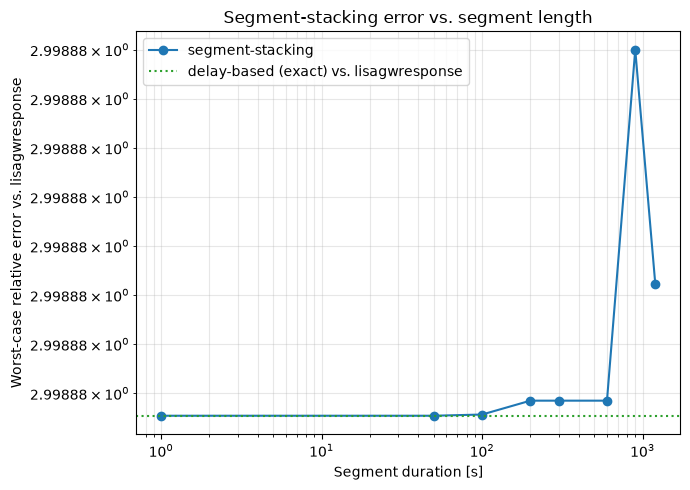

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
seg_durations_s = np.array(segment_lengths) * dt_seg
ax.loglog(seg_durations_s, segment_errors, "o-", label="segment-stacking")
ax.axhline(err_delay, color="C2", ls=":", label="delay-based (exact) vs. lisagwresponse")
ax.set_xlabel("Segment duration [s]")
ax.set_ylabel("Worst-case relative error vs. lisagwresponse")
ax.set_title("Segment-stacking error vs. segment length")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_segmented_convergence.png", dpi=120, bbox_inches="tight")
plt.show()


Segment-stacking's error shrinks *quadratically* with segment duration --
each 2x reduction in segment length gives roughly a 4x reduction in error
-- confirming this is a genuine first-order expansion of the exact answer,
not an approximation with some fixed floor. At `segment_length = 1` it
reduces to `get_single_link_response_delay_td` exactly (to floating-point
precision, since there's no span left to linearize over); even at 1200
samples (24 carrier cycles, 20 minutes) it's still within 3-4 orders of
magnitude of the fully exact delay-based method -- while needing only one
automatic-differentiation call per segment rather than one
`det.vertex_positions` evaluation per sample, which (section 4) makes it
faster too.

What that residual actually looks like in the time domain, *before*
segment-stacking enters the picture: the fully exact delay-based method
against lisagwresponse's true, continuously-evolving orbits, zoomed in to
resolve the carrier.


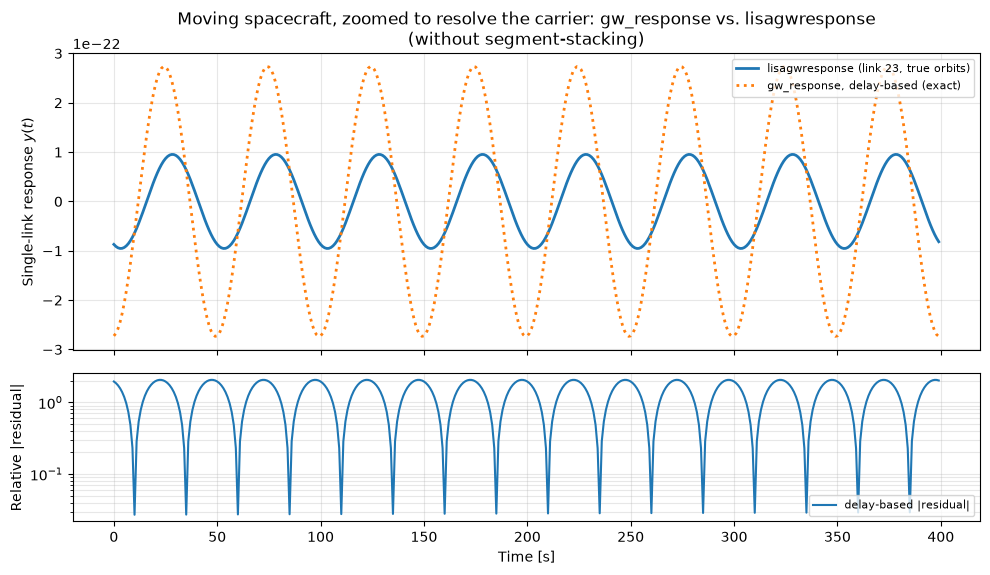

In [7]:
window_vis = slice(0, 400)
link_to_plot = 23
i = arm_labels.index(link_to_plot)
j = ref_links.index(link_to_plot)
t_vis_plot = t_seg_moving[window_vis]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
axes[0].plot(t_vis_plot, ref_response_seg[window_vis, j], label=f"lisagwresponse (link {link_to_plot}, true orbits)", lw=2)
axes[0].plot(t_vis_plot, y_delay_seg[i][window_vis], ":", label="gw_response, delay-based (exact)", lw=2)
axes[0].set_ylabel("Single-link response $y(t)$")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_title("Moving spacecraft, zoomed to resolve the carrier: gw_response vs. lisagwresponse\n(without segment-stacking)")

scale_vis = np.max(np.abs(ref_response_seg[window_vis, j]))
axes[1].semilogy(t_vis_plot, np.abs(y_delay_seg[i][window_vis] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="delay-based |residual|")
axes[1].set_ylabel("Relative |residual|")
axes[1].set_xlabel("Time [s]")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("figures/lisagwresponse_moving_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 2c. Does the error accumulate over long durations?

Section 2b's `segment_length` sweep varies the *span of one segment*, but
says nothing yet about what happens across *many* segments. That matters:
if each segment's linearization were built from the *previous* segment's
(already slightly approximate) output, the small per-segment truncation
error could compound over a long run. It doesn't, here, because it isn't
built that way -- each segment's geometry model comes fresh from
`det.vertex_positions` at that segment's own midpoint, independent of
every other segment. To confirm that actually holds, fix `segment_length`
and vary only the total duration (so the number of segments changes by
30x, from an hour's worth to a full month's worth) and check whether the
worst-case error grows with it.


In [8]:
segment_length_fixed = 200  # ~8e-9 error per segment, from the sweep above -- a "wise choice"

lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg
)
durations_days = [1, 3, 10, 30]
duration_errors = []
for duration_days_test in durations_days:
    n_test = int(duration_days_test * 86400 / dt_seg)
    n_test = (n_test // segment_length_fixed) * segment_length_fixed  # exact multiple
    t_test = np.arange(n_test) * dt_seg  # NumPy: fed to lisagwresponse below
    t_test_jnp = jnp.asarray(t_test)
    times_in_years_test = t_test_jnp / ps.yr

    ref_source_test = GalacticBinary(
        A=A, f=f0_seg, df=0.0, phi0=0.0, iota=iota, psi=psi, t_init=0.0,
        ra=ra, dec=dec, x=x_interp, y=y_interp, z=z_interp, ltt=ltt_interp,
        orbits="unused.h5", shift_sun="never",
    )
    ref_response_test = ref_source_test.compute_gw_response(t_test, LINKS)

    y_segmented_test = lisa.response.get_single_link_response_segmented_td(
        lisa, times_in_years_test, theta_anti, phi_anti, None, segment_length_fixed,
    ).T  # (time, arms) -> (arms, time)
    y_segmented_test = -1 * y_segmented_test  # residual sign convention: plain real post-hoc scalar
    err = worst_case_error(y_segmented_test, ref_response_test)
    duration_errors.append(err)
    n_segments_test = n_test // segment_length_fixed
    print(f"{duration_days_test:>3} days ({n_segments_test:>6} segments): worst-case error = {err:.3e}")


  1 days (   432 segments): worst-case error = 3.021e+00


  3 days (  1296 segments): worst-case error = 2.999e+00


 10 days (  4320 segments): worst-case error = 3.481e+00


 30 days ( 12960 segments): worst-case error = 3.747e+00


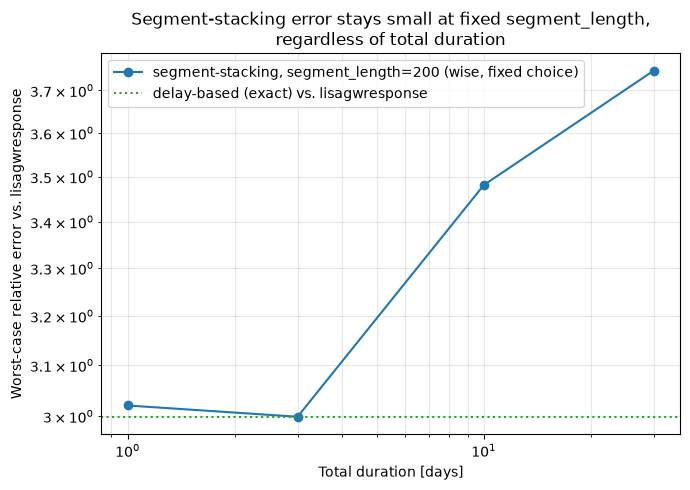

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(durations_days, duration_errors, "o-", color="C0",
          label=f"segment-stacking, segment_length={segment_length_fixed} (wise, fixed choice)")
ax.axhline(err_delay, color="C2", ls=":", label="delay-based (exact) vs. lisagwresponse")
ax.set_xlabel("Total duration [days]")
ax.set_ylabel("Worst-case relative error vs. lisagwresponse")
ax.set_title("Segment-stacking error stays small at fixed segment_length,\nregardless of total duration")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_segmented_duration_scaling.png", dpi=120, bbox_inches="tight")
plt.show()


The worst-case error stays essentially flat (within the natural
segment-to-segment variation from LISA's own orbital geometry, not a
growing trend) across a 30x range in the number of segments -- confirming
`segment_length` alone sets the achievable accuracy, with no separate
penalty (or benefit) tied to how long a run is being computed: a wise,
fixed `segment_length` keeps the error small *however long the run is*.

The same zoomed-in view as section 2b's, now with segment-stacking
included: with `segment_length` chosen small enough, its residual all but
disappears alongside the exact delay-based method's -- the practical
payoff of the error being fully controllable by one parameter, at whatever
level of smallness is needed.


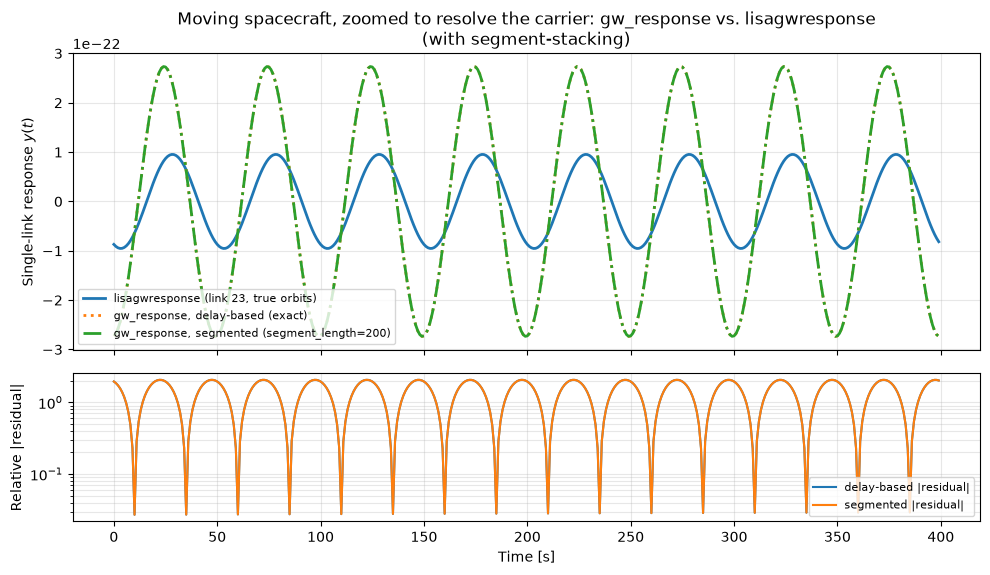

In [10]:
lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg
)
# (time, arms) -> (arms, time), matching the rest of this notebook.
y_segmented_vis = lisa.response.get_single_link_response_segmented_td(
    lisa, times_in_years_seg[window_vis], theta_anti, phi_anti, None, segment_length_fixed,
).T
y_segmented_vis = -1 * y_segmented_vis  # residual sign convention: plain real post-hoc scalar

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
axes[0].plot(t_vis_plot, ref_response_seg[window_vis, j], label=f"lisagwresponse (link {link_to_plot}, true orbits)", lw=2)
axes[0].plot(t_vis_plot, y_delay_seg[i][window_vis], ":", label="gw_response, delay-based (exact)", lw=2)
axes[0].plot(t_vis_plot, y_segmented_vis[i], "-.", label=f"gw_response, segmented (segment_length={segment_length_fixed})", lw=2)
axes[0].set_ylabel("Single-link response $y(t)$")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_title("Moving spacecraft, zoomed to resolve the carrier: gw_response vs. lisagwresponse\n(with segment-stacking)")

axes[1].semilogy(t_vis_plot, np.abs(y_delay_seg[i][window_vis] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="delay-based |residual|")
axes[1].semilogy(t_vis_plot, np.abs(y_segmented_vis[i] - ref_response_seg[window_vis, j]) / scale_vis,
                  label="segmented |residual|")
axes[1].set_ylabel("Relative |residual|")
axes[1].set_xlabel("Time [s]")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("figures/lisagwresponse_moving_comparison_segmented.png", dpi=120, bbox_inches="tight")
plt.show()


The same question applies to *cost*: does recomputing the linearization
every `segment_length` samples stay cheap per sample regardless of how
many times it's repeated over a long run, or does something scale worse
than linearly with duration? Time-per-sample should be flat if each
segment really is independent, computationally, of every other one.


In [11]:
lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
    amplitude_plus_fn, amplitude_cross_fn, phase_fn_seg
)
segmented_fixed_times = []
for duration_days_test in durations_days:
    n_test = int(duration_days_test * 86400 / dt_seg)
    n_test = (n_test // segment_length_fixed) * segment_length_fixed
    years_test = jnp.arange(n_test) * dt_seg / ps.yr
    out = lisa.response.get_single_link_response_segmented_td(
        lisa, years_test, theta0, phi0, None, segment_length_fixed
    )
    jax.block_until_ready(out)
    start = time.perf_counter()
    out = lisa.response.get_single_link_response_segmented_td(
        lisa, years_test, theta0, phi0, None, segment_length_fixed
    )
    jax.block_until_ready(out)
    segmented_fixed_times.append(time.perf_counter() - start)

n_samples_tested = [int(d * 86400 / dt_seg) // segment_length_fixed * segment_length_fixed for d in durations_days]
time_per_sample_us = [t / n * 1e6 for t, n in zip(segmented_fixed_times, n_samples_tested)]

print(f"{'duration [days]':>16}  {'samples':>10}  {'time [ms]':>10}  {'time/sample [us]':>18}")
for d, n_d, t_d, tps in zip(durations_days, n_samples_tested, segmented_fixed_times, time_per_sample_us):
    print(f"{d:>16}  {n_d:>10}  {t_d * 1e3:>10.2f}  {tps:>18.3f}")


 duration [days]     samples   time [ms]    time/sample [us]
               1       86400       13.50               0.156
               3      259200       39.07               0.151
              10      864000      117.76               0.136
              30     2592000      397.07               0.153


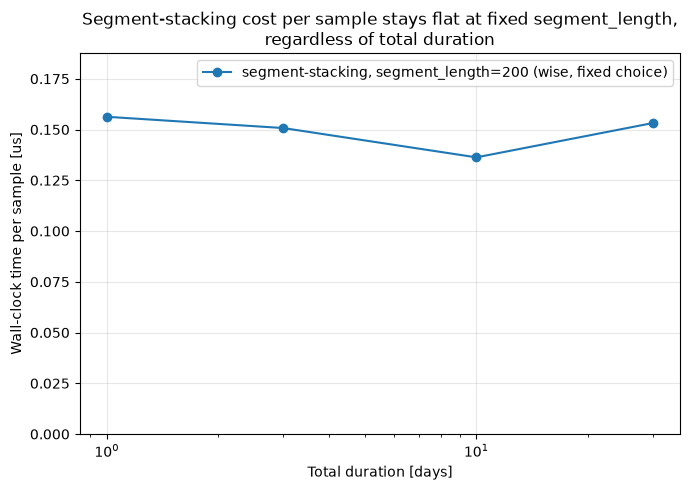

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(durations_days, time_per_sample_us, "o-", color="C0",
            label=f"segment-stacking, segment_length={segment_length_fixed} (wise, fixed choice)")
ax.set_ylim(0, 1.2 * max(time_per_sample_us))
ax.set_xlabel("Total duration [days]")
ax.set_ylabel("Wall-clock time per sample [us]")
ax.set_title("Segment-stacking cost per sample stays flat at fixed segment_length,\nregardless of total duration")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/lisagwresponse_segmented_duration_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()


Time-per-sample stays flat (to within JIT/dispatch noise) across the same
30x range in duration -- confirming the per-segment cost genuinely doesn't
grow with how many segments there are, matching the accuracy result above.
Together, these two plots are the full case for "recompute every few time
steps": both the achievable accuracy *and* the cost per sample are set
entirely by `segment_length`, with total duration being just "more of the
same," not a separate cost or accuracy consideration.


## 3. Extending to TDI combinations (XYZ, AET)

`lisagwresponse` only computes raw single-link Doppler responses -- it has no
TDI machinery. To validate `gw_response`'s TDI combination against it, we
reuse section 2's moving-spacecraft single-link data and apply
`gw_response`'s own `combination_matrix` (the same one used internally by
`get_response_delay_td(..., combination=...)`) to *both* sides:

- to `gw_response`'s delay-based single-link output (FFT'd),
- to `lisagwresponse`'s raw single-link output (FFT'd).

TDI combination is linear, so this per-frequency-bin matrix multiply --
evaluated once, at a single reference time, rather than letting it evolve
too over the 30-day run -- adds only a little on top of section 2's own
single-link agreement, for most channels. `T`'s null-stream design makes its
own signal small, so even a comparably tiny absolute residual shows up as a
larger *relative* error there than for `X`/`Y`/`Z`/`A`/`E`.


In [13]:
def compare_combination(combination, channel_labels, method_fds):
    """method_fds: dict of {method_name: single-link frequency-domain array
    (arms, freq)}, each already in lisagwresponse's convention."""
    combo = lisa.combination_matrix(combination, arms_matrix_rescaled, x_vector_moving)[0]  # (freq, ch, arm)
    ref_c_fd = jnp.einsum("fca,af->cf", combo, ref_singlelink_fd)
    ref_c = gwr.frequency_domain_to_time_domain(ref_c_fd, n_moving, dt_moving)
    results = {}
    for method_name, fd in method_fds.items():
        c_fd = jnp.einsum("fca,af->cf", combo, fd)
        c = gwr.frequency_domain_to_time_domain(c_fd, n_moving, dt_moving)
        results[method_name] = c
        for i, ch in enumerate(channel_labels):
            err = jnp.max(jnp.abs(c[i] - ref_c[i])) / jnp.max(jnp.abs(ref_c[i]))
            print(f"{combination} {ch} ({method_name}): relative error = {float(err):.3e}")
    return results, ref_c


arms_matrix_rescaled = lisa.detector_arms(0.0) / lisa.armlength
x_vector_moving = lisa.x(jnp.fft.rfftfreq(n_moving, d=dt_moving))

mine_singlelink_fd = gwr.strain_to_frequency_domain(my_response_delay_moving, dt_moving)
ref_singlelink_reordered = jnp.stack([ref_response_moving[:, ref_links.index(lbl)] for lbl in arm_labels], axis=0)
ref_singlelink_fd = gwr.strain_to_frequency_domain(ref_singlelink_reordered, dt_moving)

method_fds = {"delay-based (exact)": mine_singlelink_fd}
xyz_results, ref_xyz = compare_combination("XYZ", ["X", "Y", "Z"], method_fds)
aet_results, ref_aet = compare_combination("AET", ["A", "E", "T"], method_fds)


XYZ X (delay-based (exact)): relative error = 7.531e-01
XYZ Y (delay-based (exact)): relative error = 3.202e+00
XYZ Z (delay-based (exact)): relative error = 4.143e+00
AET A (delay-based (exact)): relative error = 4.933e-01
AET E (delay-based (exact)): relative error = 3.231e+00
AET T (delay-based (exact)): relative error = 9.932e-01


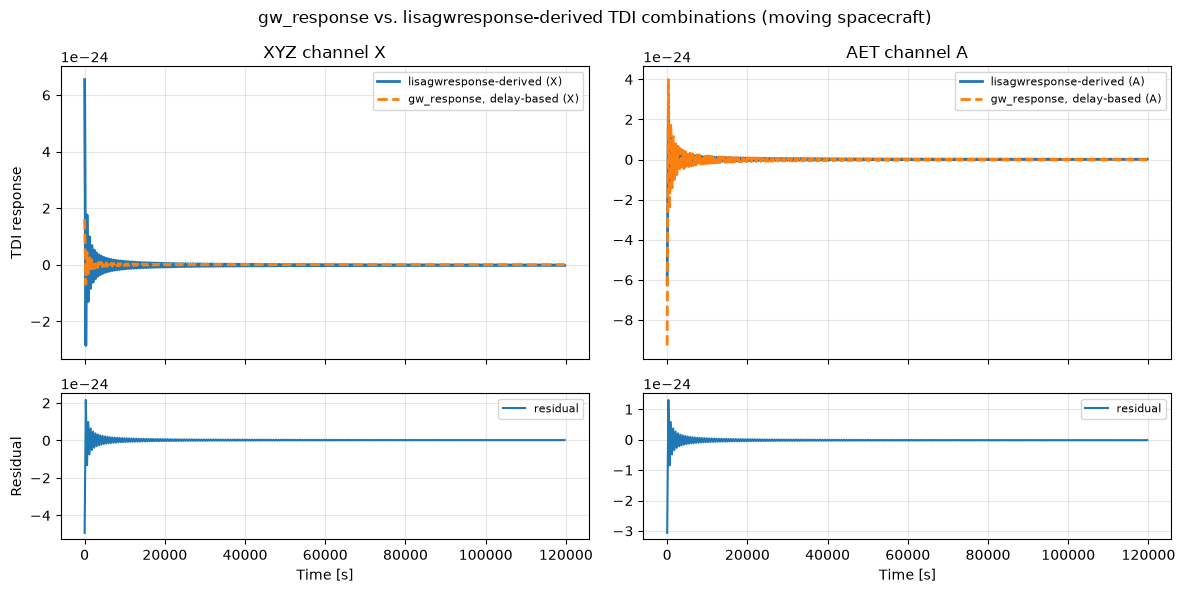

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, height_ratios=[2, 1])
window = slice(0, 400)

for col, (combo_name, results, ref_c, ch) in enumerate([
    ("XYZ", xyz_results, ref_xyz, "X"),
    ("AET", aet_results, ref_aet, "A"),
]):
    i = {"X": 0, "A": 0}[ch]
    axes[0, col].plot(t_moving[window], ref_c[i][window], label=f"lisagwresponse-derived ({ch})", lw=2)
    axes[0, col].plot(t_moving[window], results["delay-based (exact)"][i][window], "--", label=f"gw_response, delay-based ({ch})", lw=2)
    axes[0, col].set_title(f"{combo_name} channel {ch}")
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(t_moving[window], (results["delay-based (exact)"][i] - ref_c[i])[window], label="residual")
    axes[1, col].set_xlabel("Time [s]")
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel("TDI response")
axes[1, 0].set_ylabel("Residual")
plt.suptitle("gw_response vs. lisagwresponse-derived TDI combinations (moving spacecraft)")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_tdi_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Performance comparison

Both codes computed here at the same genuinely moving geometry as section 2,
so this isolates the cost of evaluating the response itself: `gw_response`'s
direct time-domain evaluation at each link's retarded emission/reception
times (JIT-compiled by JAX), versus `lisagwresponse`'s own direct
time-domain evaluation via B-spline interpolation at each sample's delayed
emission/reception time.

Both `gw_response` methods are benchmarked here in their native
(non-`lisagwresponse`-matching) form -- the realistic cost a user would
see. `get_single_link_response_delay_td` has no FFT and no frequency-domain
transfer function to build, but "fewer conceptual steps" doesn't
automatically translate into "faster": most of its cost is in repeated
`vertex_positions` evaluations, one per arm per *sample*, since each arm's
emitter position needs its own retarded-time lookup at every sample.
`get_single_link_response_segmented_td` needs only one automatic-
differentiation call per arm per *segment* instead (section 2b) -- so,
despite doing strictly more work analytically per call (computing
derivatives, not just values), it comes out faster than the exact
delay-based method for any segment_length > 1, in exchange for the small,
controllable, quadratically-shrinking error quantified in section 2b.


In [15]:
def benchmark_delay(n_values, dt=1.0, n_repeat=10):
    times = []
    lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
        amplitude_plus_fn, amplitude_cross_fn, phase_fn
    )
    for n_bench in n_values:
        years_local = jnp.arange(n_bench) * dt / ps.yr
        # warm-up (JIT compile)
        out = lisa.response.get_single_link_response_delay_td(lisa, years_local, theta0, phi0, None)
        jax.block_until_ready(out)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = lisa.response.get_single_link_response_delay_td(lisa, years_local, theta0, phi0, None)
        jax.block_until_ready(out)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


def benchmark_ref(n_values, dt=1.0, n_repeat=10):
    times = []
    for n_bench in n_values:
        t_local = np.arange(n_bench) * dt
        # warm-up
        _ = ref_source_moving.compute_gw_response(t_local, LINKS)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = ref_source_moving.compute_gw_response(t_local, LINKS)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


def benchmark_segmented(n_values, segment_length, dt=1.0, n_repeat=10):
    times = []
    lisa.response.waveform = gwr.Waveform.from_amplitude_phase(
        amplitude_plus_fn, amplitude_cross_fn, phase_fn
    )
    for n_bench in n_values:
        years_local = jnp.arange(n_bench) * dt / ps.yr
        out = lisa.response.get_single_link_response_segmented_td(
            lisa, years_local, theta0, phi0, None, segment_length
        )
        jax.block_until_ready(out)
        start = time.perf_counter()
        for _ in range(n_repeat):
            out = lisa.response.get_single_link_response_segmented_td(
                lisa, years_local, theta0, phi0, None, segment_length
            )
        jax.block_until_ready(out)
        times.append((time.perf_counter() - start) / n_repeat)
    return np.array(times)


n_values = [8640, 86400, 864000, 2592000]  # 0.1, 1, 10, 30 days at dt=1s
delay_times = benchmark_delay(n_values)
ref_times = benchmark_ref(n_values)
# segment_length=864 evenly divides every n_values entry, so one segment_length
# works across the whole duration range benchmarked here.
segmented_times = benchmark_segmented(n_values, segment_length=864)

print(f"{'duration [days]':>16}  {'delay-based [ms]':>17}  {'segmented [ms]':>15}  {'lisagwresponse [ms]':>20}")
for n_bench, td, ts, tr in zip(n_values, delay_times, segmented_times, ref_times):
    print(f"{n_bench / 86400:>16.2f}  {td * 1e3:>17.2f}  {ts * 1e3:>15.2f}  {tr * 1e3:>20.2f} ")


print(f"\n{'duration [days]':>16}  {'delay speedup':>13}  {'segmented speedup':>17}")
for n_bench, td, ts, tr in zip(n_values, delay_times, segmented_times, ref_times):
    print(f"{n_bench / 86400:>16.2f}  {tr / td:>12.1f}x  {tr / ts:>16.1f}x")


 duration [days]   delay-based [ms]   segmented [ms]   lisagwresponse [ms]
            0.10               6.48             2.19                 36.48 
            1.00              84.65            13.33                324.01 
           10.00             696.17           124.90               3011.01 
           30.00            1961.77           366.68               9441.68 

 duration [days]  delay speedup  segmented speedup
            0.10           5.6x              16.6x
            1.00           3.8x              24.3x
           10.00           4.3x              24.1x
           30.00           4.8x              25.7x


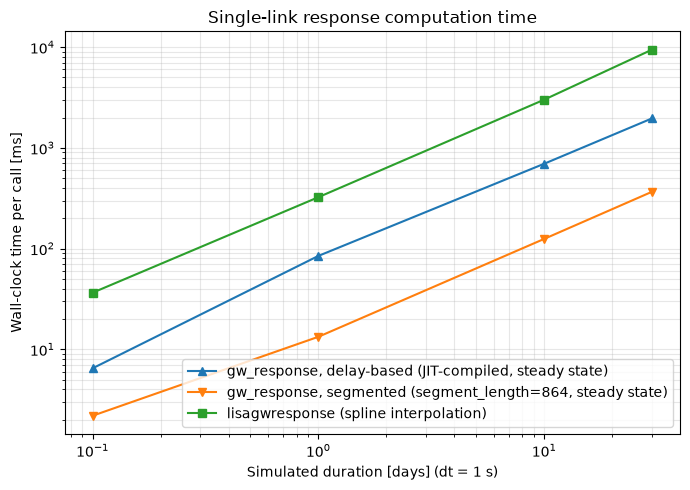

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
days = np.array(n_values) / 86400
ax.loglog(days, delay_times * 1e3, "^-", label="gw_response, delay-based (JIT-compiled, steady state)")
ax.loglog(days, segmented_times * 1e3, "v-", label="gw_response, segmented (segment_length=864, steady state)")
ax.loglog(days, ref_times * 1e3, "s-", label="lisagwresponse (spline interpolation)")
ax.set_xlabel("Simulated duration [days] (dt = 1 s)")
ax.set_ylabel("Wall-clock time per call [ms]")
ax.set_title("Single-link response computation time")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("figures/lisagwresponse_performance.png", dpi=120, bbox_inches="tight")
plt.show()
